In [1]:
#| default_exp statsplots

# Statistical Plots (`statsplots`)

> Diagnostic plotting utilities for time series analysis and forecasting workflows, including Cross-Correlation (CCF), Autocorrelation (ACF), and Partial Autocorrelation (PACF) visualizations with support for single series and multi-series subplot grids.

In [2]:
#| export
from __future__ import annotations
from typing import Union, Literal, Sequence
import warnings
from statistics import NormalDist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from statsmodels.tsa.stattools import ccf, acf, pacf

ArrayLike = Union[np.ndarray, list, pd.Series]

In [3]:
#| export
def _clean_series(s: ArrayLike, name: str = "series") -> tuple[np.ndarray, str]:
    """Sanitize time series data for plotting, returning (1D array, label)."""
    label = getattr(s, "name", name) if name == "series" else name
    if label is None:
        label = "series"
    label = str(label)

    if isinstance(s, pd.Series):
        arr = s.dropna().to_numpy(dtype=float)
    elif isinstance(s, (list, tuple)):
        arr = np.asarray(s, dtype=float)
        arr = arr[~np.isnan(arr)]
    elif isinstance(s, np.ndarray):
        arr = s.astype(float).ravel()
        arr = arr[~np.isnan(arr)]
    else:
        arr = np.asarray(s, dtype=float).ravel()
        arr = arr[~np.isnan(arr)]

    if len(arr) == 0:
        raise ValueError(f"Series '{label}' is empty or contains only NaNs.")
    return arr, label

## Cross-Correlation Function (CCF) Plotting

`plot_ccf` (and alias `ccf_plot`) visualizes the sample cross-correlation between two time series $x_t$ (e.g., exogenous driver) and $y_t$ (e.g., target series) across multiple forward lags, along with statistical confidence intervals.

- **Parametric Figure Sizing**: Fully customizable `figsize`.
- **Confidence Bands**: Lag-adjusted ($z / \sqrt{n-k}$) or fixed white-noise ($z / \sqrt{n}$) bands.
- **Composable**: Accepts an optional `ax` parameter to embed within custom matplotlib figures.

In [4]:
#| export
def plot_ccf(
    x: ArrayLike,
    y: ArrayLike,
    lags: int = 20,
    alpha: float = 0.05,
    adjusted: bool = True,
    figsize: tuple[float, float] = (10, 4),
    title: str | None = None,
    ax: plt.Axes | None = None,
    color: str = "#1f77b4",
) -> plt.Axes:
    """
    Plot the sample cross-correlation function (CCF) between two time series.

    Parameters
    ----------
    x : ArrayLike
        First time series (e.g. predictor or input series x_t).
    y : ArrayLike
        Second time series (e.g. target or output series y_t).
    lags : int, default 20
        Number of forward lags to compute and plot (lags 0 through lags).
    alpha : float, default 0.05
        Significance level for confidence intervals (e.g. 0.05 for 95% CI).
    adjusted : bool, default True
        If True, uses lag-specific adjusted CI (z / sqrt(n - k));
        if False, uses fixed white-noise CI (z / sqrt(n)).
    figsize : tuple of float, default (10, 4)
        Figure dimensions (width, height) in inches. Ignored if `ax` is provided.
    title : str, optional
        Custom title for the plot. If None, defaults to "Cross-Correlation Function (CCF)".
    ax : matplotlib.axes.Axes, optional
        Target matplotlib axes to draw on. If None, a new figure is created.
    color : str, default "#1f77b4"
        Color for stem markers and lines.

    Returns
    -------
    matplotlib.axes.Axes
        The axes object containing the CCF plot.
    """
    arr_x, name_x = _clean_series(x, "x")
    arr_y, name_y = _clean_series(y, "y")
    n = min(len(arr_x), len(arr_y))
    if len(arr_x) != len(arr_y):
        warnings.warn(
            f"Series length mismatch: x has {len(arr_x)} and y has {len(arr_y)}. Truncating to {n}.",
            UserWarning,
            stacklevel=2,
        )
        arr_x = arr_x[:n]
        arr_y = arr_y[:n]

    if lags >= n:
        raise ValueError(f"lags ({lags}) must be smaller than series length ({n}).")

    z = NormalDist().inv_cdf(1 - alpha / 2)
    cross_corrs = ccf(arr_x, arr_y, adjusted=adjusted)[: lags + 1]
    lag_indices = np.arange(0, lags + 1)

    if adjusted:
        ci = np.array([z / np.sqrt(n - k) for k in lag_indices])
    else:
        ci = np.full(lags + 1, z / np.sqrt(n))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    markerline, stemlines, baseline = ax.stem(lag_indices, cross_corrs, linefmt=color, markerfmt="o", basefmt="k-")
    plt.setp(markerline, color=color, markersize=5)
    plt.setp(stemlines, color=color, linewidth=1.5)
    plt.setp(baseline, color="gray", linewidth=0.8, linestyle="--")

    ax.fill_between(lag_indices, ci, -ci, color=color, alpha=0.18, label=f"{int((1-alpha)*100)}% CI")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

    plot_title = title if title is not None else f"CCF: {name_x} vs {name_y}"
    ax.set_title(plot_title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Lag (k)", fontsize=10)
    ax.set_ylabel("Cross-correlation", fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_ylim(-1.05, 1.05)

    return ax


# Backward-compatible alias
ccf_plot = plot_ccf

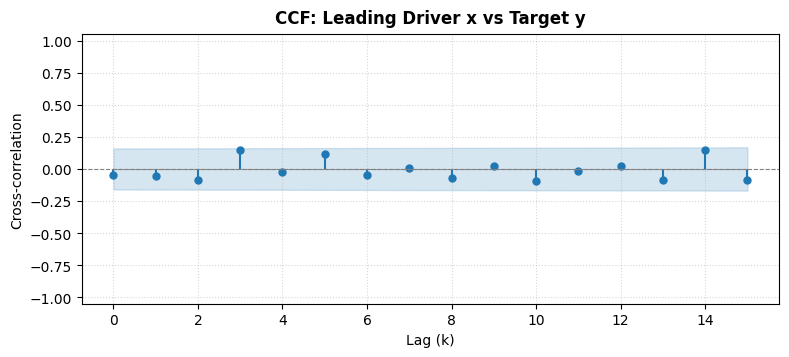

In [5]:
# Example: Plot CCF for a single pair of time series
np.random.seed(42)
x_series = np.random.normal(size=150)
y_series = np.roll(x_series, 2) + 0.3 * np.random.normal(size=150)

ax = plot_ccf(x_series, y_series, lags=15, figsize=(9, 3.5), title="CCF: Leading Driver x vs Target y")
assert ax is not None
plt.show()

## Multi-Pair Cross-Correlation Plots

`plot_ccf_pairs` automates the visualization of cross-correlations across multiple candidate predictor features against a primary target time series in a clean subplot grid.

In [6]:
#| export
def plot_ccf_pairs(
    data: pd.DataFrame | dict,
    target: str | ArrayLike | None = None,
    predictors: Sequence[str] | None = None,
    lags: int = 20,
    alpha: float = 0.05,
    adjusted: bool = True,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
    color: str = "#1f77b4",
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot CCF subplots across multiple pairs or multiple predictors against a target series.

    Parameters
    ----------
    data : pd.DataFrame or dict
        Dataset containing multiple time series.
    target : str or ArrayLike, optional
        Target variable (y_t). If `data` is a DataFrame and `target` is a string,
        computes CCF between each predictor column and `target`.
    predictors : list of str, optional
        List of predictor column names to evaluate against `target`.
        If None, all other columns in `data` are treated as predictors.
    lags : int, default 20
        Number of lags to compute for each pair.
    alpha : float, default 0.05
        Significance level for confidence intervals.
    adjusted : bool, default True
        Whether to use lag-adjusted confidence intervals.
    ncols : int, default 2
        Number of subplot columns in the figure grid.
    figsize : tuple of float, optional
        Overall figure dimensions (width, height). If None, calculated automatically based on subplots.
    color : str, default "#1f77b4"
        Color for stem markers and confidence bands.

    Returns
    -------
    tuple of (matplotlib.figure.Figure, np.ndarray of Axes)
        The created figure and array of axes.
    """
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    elif isinstance(data, dict):
        df = pd.DataFrame(data)
    else:
        raise ValueError("data must be a pandas DataFrame or dictionary of series.")

    if target is None:
        raise ValueError("target must be specified (e.g. column name in DataFrame or target series).")

    if isinstance(target, str):
        if target not in df.columns:
            raise ValueError(f"Target column '{target}' not found in data.")
        target_series = df[target]
        target_name = target
        available_preds = [c for c in df.columns if c != target]
    else:
        target_series = target
        target_name = getattr(target, "name", "target") or "target"
        available_preds = list(df.columns)

    if predictors is not None:
        pred_cols = [p for p in predictors if p in df.columns]
    else:
        pred_cols = available_preds

    if len(pred_cols) == 0:
        raise ValueError("No valid predictor series found to compute CCF pairs.")

    n_plots = len(pred_cols)
    nrows = int(np.ceil(n_plots / ncols))

    if figsize is None:
        figsize = (6.0 * ncols, 3.8 * nrows)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    flat_axes = axes.flatten()

    for idx, col in enumerate(pred_cols):
        ax_curr = flat_axes[idx]
        plot_ccf(
            x=df[col],
            y=target_series,
            lags=lags,
            alpha=alpha,
            adjusted=adjusted,
            title=f"CCF: {col} -> {target_name}",
            ax=ax_curr,
            color=color,
        )

    # Hide unused axes if any
    for idx in range(n_plots, len(flat_axes)):
        fig.delaxes(flat_axes[idx])

    fig.tight_layout()
    return fig, axes

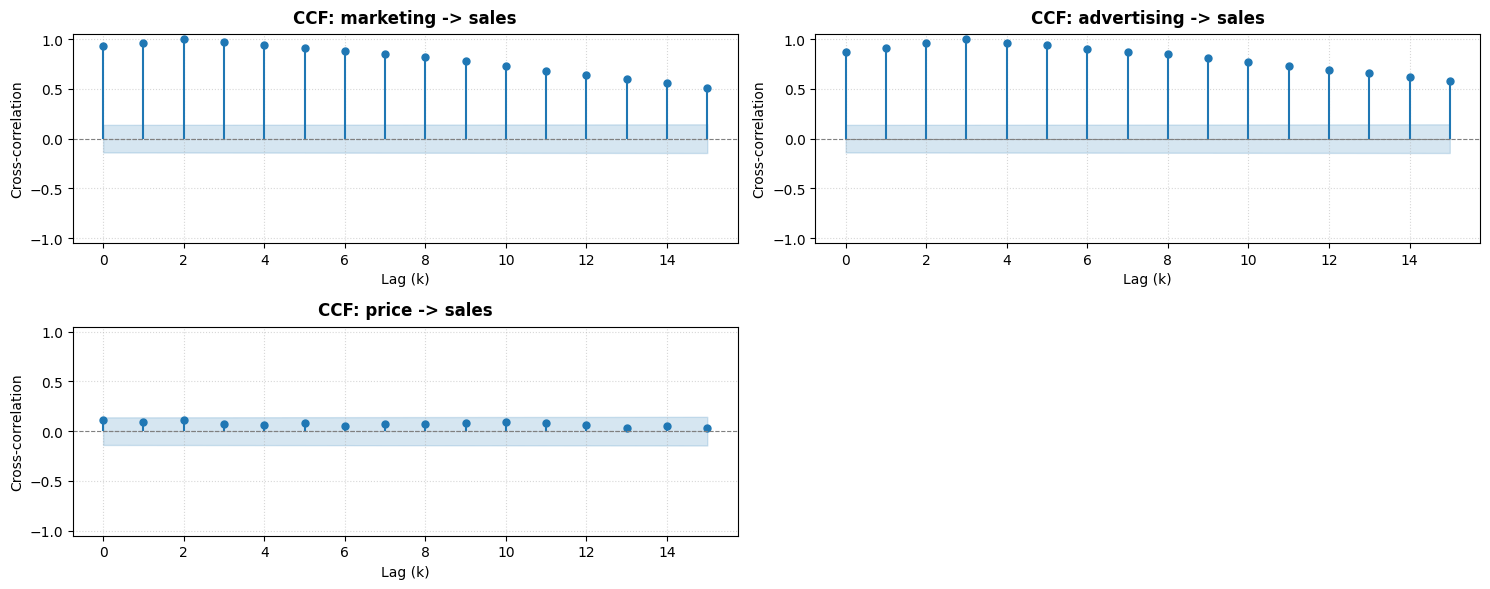

In [22]:
#| hide

# Example: Multi-pair CCF across multiple predictors and a target
np.random.seed(42)
n_samples = 200
sales = np.cumsum(np.random.normal(size=n_samples))
marketing = np.roll(sales, 2) + np.random.normal(scale=0.5, size=n_samples)
advertising = np.roll(sales, 3) + np.random.normal(scale=0.8, size=n_samples)
price = np.random.normal(size=n_samples)

multivariate_df = pd.DataFrame({
    "sales": sales,
    "marketing": marketing,
    "advertising": advertising,
    "price": price
})

fig_ccf, axes_ccf = plot_ccf_pairs(multivariate_df, target="sales", lags=15, ncols=2, figsize=(15, 6))
assert fig_ccf is not None
plt.show()

## Autocorrelation (ACF) and Partial Autocorrelation (PACF) Plots

`plot_acf_pacf` provides a versatile diagnostic plotting interface for time series serial dependence.

### Key Capabilities:
- **Flexible Diagnostics**:
  - `kind="both"`: Plots both ACF and PACF.
  - `kind="acf"`: Plots ACF only.
  - `kind="pacf"`: Plots PACF only.
- **Layout Control**:
  - `layout="horizontal"`: Places ACF and PACF side-by-side ($1 \times 2$).
  - `layout="vertical"`: Stacks ACF above PACF ($2 \times 1$).
- **Multi-Series Batch Plotting**: Pass a single Series, a dictionary, a list of series, or a multi-column DataFrame to generate diagnostic rows for each series in one unified figure.
- **Parametric Controls**: Custom `lags`, `figsize`, `alpha` significance levels, and `zero` lag toggle.

In [8]:
#| export
def plot_acf_pacf(
    series: ArrayLike | pd.DataFrame | dict,
    lags: int = 30,
    kind: Literal["both", "acf", "pacf"] = "both",
    layout: Literal["horizontal", "vertical"] = "horizontal",
    alpha: float = 0.05,
    zero: bool = False,
    pacf_method: str = "ywm",
    figsize: tuple[float, float] | None = None,
    title: str | None = None,
    ax: plt.Axes | np.ndarray | None = None,
    color_acf: str = "#1f77b4",
    color_pacf: str = "#ff7f0e",
) -> tuple[plt.Figure, Union[plt.Axes, np.ndarray]]:
    """
    Plot Autocorrelation Function (ACF), Partial Autocorrelation Function (PACF), or both.
    Supports single or multiple time series.

    Parameters
    ----------
    series : ArrayLike, pd.DataFrame, or dict
        Time series data to analyze (single 1D series, list of series, or multi-column DataFrame).
    lags : int, default 30
        Number of lags to compute and display.
    kind : {"both", "acf", "pacf"}, default "both"
        Which diagnostic plot(s) to generate.
    layout : {"horizontal", "vertical"}, default "horizontal"
        Subplot orientation when `kind="both"`.
        - "horizontal": ACF and PACF side-by-side (1 row, 2 columns per series).
        - "vertical": ACF stacked above PACF (2 rows, 1 column per series).
    alpha : float, default 0.05
        Significance level for confidence interval bands.
    zero : bool, default False
        Whether to include lag 0 in the plots. Default False focuses on informative lags >= 1.
    pacf_method : str, default "ywm"
        Estimation method for PACF calculation ('ywm', 'ywadjusted', 'ols', 'ld').
    figsize : tuple of float, optional
        Dimensions (width, height) of the figure. If None, calculated automatically.
    title : str, optional
        Custom figure/subplot title or prefix.
    ax : matplotlib.axes.Axes or np.ndarray, optional
        Pre-existing axes to draw on (single series only).
    color_acf : str, default "#1f77b4"
        Color for ACF stem plot and confidence intervals.
    color_pacf : str, default "#ff7f0e"
        Color for PACF stem plot and confidence intervals.

    Returns
    -------
    tuple of (matplotlib.figure.Figure, matplotlib.axes.Axes or np.ndarray)
        Figure and axes object(s).
    """
    kind_clean = kind.strip().lower()
    if kind_clean not in ["both", "acf", "pacf"]:
        raise ValueError("kind must be 'both', 'acf', or 'pacf'.")

    layout_clean = layout.strip().lower()
    if layout_clean not in ["horizontal", "vertical"]:
        raise ValueError("layout must be 'horizontal' or 'vertical'.")

    # Multi-series handling (DataFrame or dict with multiple series)
    if isinstance(series, (pd.DataFrame, dict)):
        df = pd.DataFrame(series)
        series_items = [(col, df[col].dropna().to_numpy(dtype=float)) for col in df.columns]
    elif isinstance(series, (list, tuple)) and len(series) > 0 and isinstance(series[0], (pd.Series, np.ndarray, list)):
        series_items = [(getattr(s, "name", f"Series {i+1}") or f"Series {i+1}", _clean_series(s)[0]) for i, s in enumerate(series)]
    else:
        arr, s_name = _clean_series(series, "Series")
        series_items = [(title if title else s_name, arr)]

    n_series = len(series_items)
    z = NormalDist().inv_cdf(1 - alpha / 2)

    # Determine grid structure per series
    if kind_clean == "both":
        plots_per_series = 2
        if layout_clean == "horizontal":
            nrows = n_series
            ncols = 2
            default_figsize = (14, 3.8 * n_series)
        else:
            nrows = 2 * n_series
            ncols = 1
            default_figsize = (8.5, 3.2 * 2 * n_series)
    else:
        plots_per_series = 1
        nrows = n_series
        ncols = 1
        default_figsize = (9.0, 3.5 * n_series)

    if figsize is None:
        figsize = default_figsize

    if ax is None:
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    else:
        if n_series > 1:
            raise ValueError("Passing custom `ax` is only supported for single series.")
        if isinstance(ax, plt.Axes):
            axes = np.array([[ax]])
            fig = ax.figure
        else:
            axes = np.asarray(ax).reshape(nrows, ncols)
            fig = axes.flat[0].figure

    for s_idx, (s_name, arr) in enumerate(series_items):
        n = len(arr)
        effective_lags = min(lags, n - 1)
        start_lag = 0 if zero else 1
        lag_range = np.arange(start_lag, effective_lags + 1)
        ci_bound = z / np.sqrt(n)

        # Plot ACF
        if kind_clean in ["both", "acf"]:
            acf_vals = acf(arr, nlags=effective_lags, fft=True)[start_lag: effective_lags + 1]
            if kind_clean == "both":
                if layout_clean == "horizontal":
                    ax_acf = axes[s_idx, 0]
                else:
                    ax_acf = axes[2 * s_idx, 0]
            else:
                ax_acf = axes[s_idx, 0]

            markerline, stemlines, baseline = ax_acf.stem(
                lag_range, acf_vals, linefmt=color_acf, markerfmt="o", basefmt="k-"
            )
            plt.setp(markerline, color=color_acf, markersize=4.5)
            plt.setp(stemlines, color=color_acf, linewidth=1.4)
            plt.setp(baseline, color="gray", linewidth=0.8, linestyle="--")

            ax_acf.fill_between(lag_range, ci_bound, -ci_bound, color=color_acf, alpha=0.18, label=f"{int((1-alpha)*100)}% CI")
            ax_acf.axhline(0, color="gray", linestyle="--", linewidth=0.8)
            ax_acf.set_title(f"ACF: {s_name}", fontsize=11, fontweight="bold", pad=6)
            ax_acf.set_xlabel("Lag", fontsize=9.5)
            ax_acf.set_ylabel("Autocorrelation", fontsize=9.5)
            ax_acf.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax_acf.grid(True, linestyle=":", alpha=0.5)
            ax_acf.set_ylim(-1.05, 1.05)

        # Plot PACF
        if kind_clean in ["both", "pacf"]:
            pacf_vals = pacf(arr, nlags=effective_lags, method=pacf_method)[start_lag: effective_lags + 1]
            if kind_clean == "both":
                if layout_clean == "horizontal":
                    ax_pacf = axes[s_idx, 1]
                else:
                    ax_pacf = axes[2 * s_idx + 1, 0]
            else:
                ax_pacf = axes[s_idx, 0]

            markerline, stemlines, baseline = ax_pacf.stem(
                lag_range, pacf_vals, linefmt=color_pacf, markerfmt="o", basefmt="k-"
            )
            plt.setp(markerline, color=color_pacf, markersize=4.5)
            plt.setp(stemlines, color=color_pacf, linewidth=1.4)
            plt.setp(baseline, color="gray", linewidth=0.8, linestyle="--")

            ax_pacf.fill_between(lag_range, ci_bound, -ci_bound, color=color_pacf, alpha=0.18, label=f"{int((1-alpha)*100)}% CI")
            ax_pacf.axhline(0, color="gray", linestyle="--", linewidth=0.8)
            ax_pacf.set_title(f"PACF: {s_name}", fontsize=11, fontweight="bold", pad=6)
            ax_pacf.set_xlabel("Lag", fontsize=9.5)
            ax_pacf.set_ylabel("Partial Autocorrelation", fontsize=9.5)
            ax_pacf.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax_pacf.grid(True, linestyle=":", alpha=0.5)
            ax_pacf.set_ylim(-1.05, 1.05)

    fig.tight_layout()
    return fig, axes.squeeze()

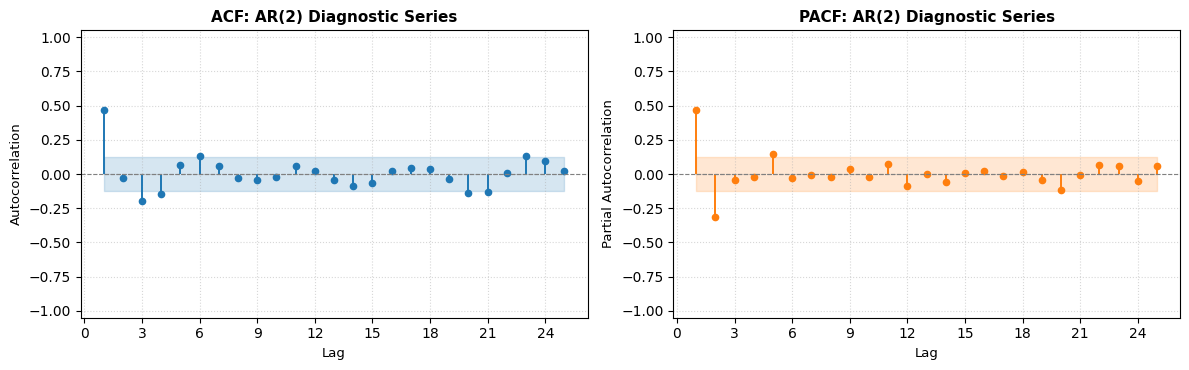

In [19]:
#| hide
# Example 1: ACF & PACF side-by-side for a single time series
np.random.seed(42)
ar_series = np.zeros(250)
for t in range(2, 250):
    ar_series[t] = 0.65 * ar_series[t - 1] - 0.3 * ar_series[t - 2] + np.random.normal()

fig_single, axes_single = plot_acf_pacf(
    ar_series,
    lags=25,
    kind="both",
    layout="horizontal",
    figsize=(12, 3.8),
    title="AR(2) Diagnostic Series"
)
assert fig_single is not None
plt.show()

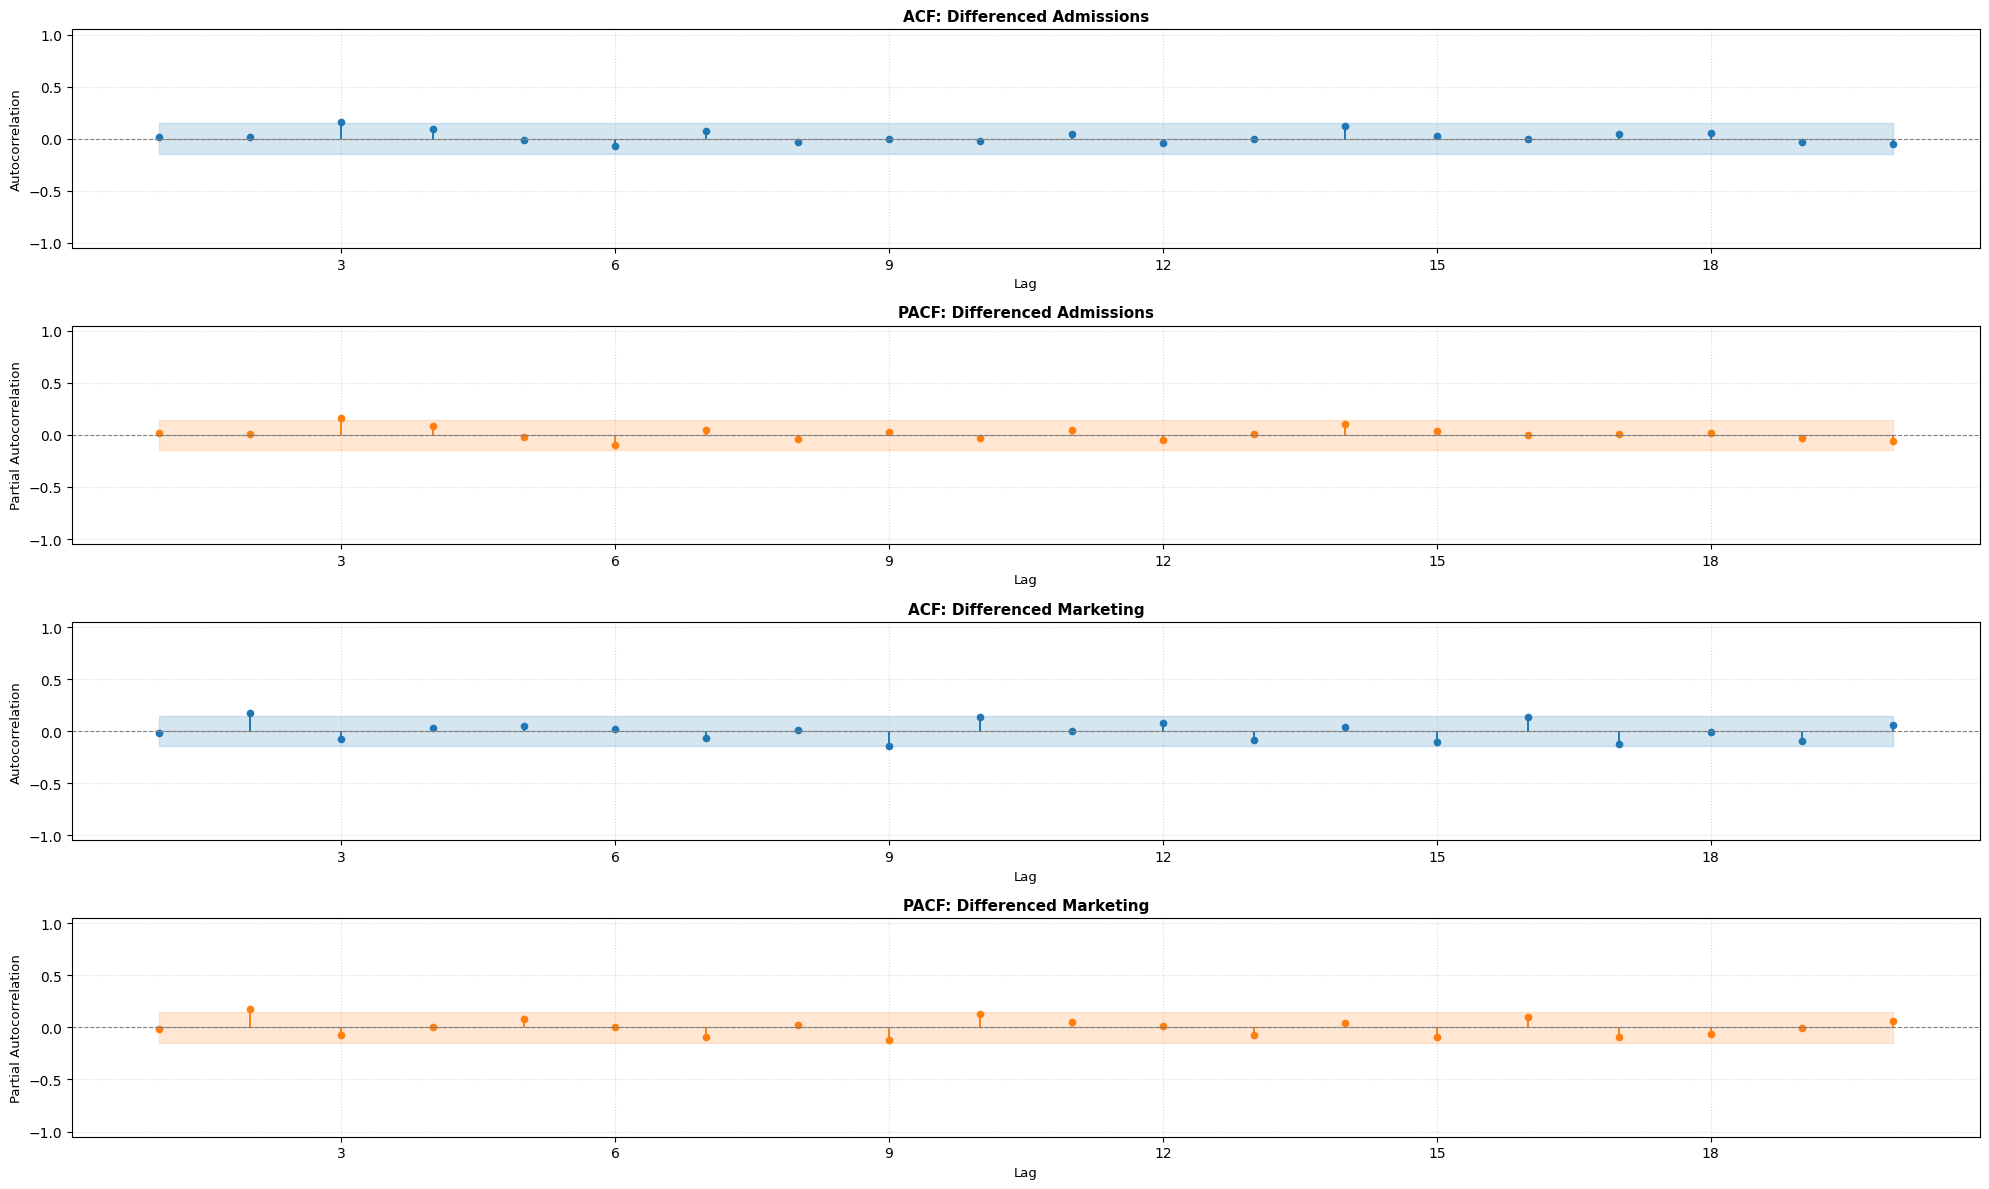

In [18]:
#| hide

# Example 2: Batch ACF & PACF across multiple series in a DataFrame
sample_df = pd.DataFrame({
    "Differenced Admissions": np.diff(np.cumsum(np.random.normal(size=180))),
    "Differenced Marketing": np.diff(np.cumsum(np.random.normal(size=180))),
})

fig_multi, axes_multi = plot_acf_pacf(
    sample_df,
    lags=20,
    kind="both",
    layout="vertical",
    figsize=(20, 12)
)
assert fig_multi is not None
plt.show()